comentario: voy a modificarlo para 2 archivos de prueba de 10 letras hechos con la version original.

okeeeey aparentemente ya quedo joya. Hay no mas que hacer una copoia para 7 y 13

In [1]:
import numpy as np
import pandas as pd
from google.colab import drive
import os
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
drive.mount('/content/drive', force_remount=True)
os.chdir('/content/drive/MyDrive/Neurociencia Cognitiva/TP FINAL/archivos prueba')

Mounted at /content/drive


In [4]:
cant_archivos = len(os.listdir('/content/drive/MyDrive/Neurociencia Cognitiva/TP FINAL/archivos prueba')) # no le resto el excel
print(cant_archivos)

posicion =[]
respuesta = []
tiempo = []

for i in range(0, cant_archivos):
    nombre_archivo = f'data10_{i}.csv'  #cambie el nombre
    df = pd.read_csv(nombre_archivo)

    posicion = list(posicion) + list(df.iloc[:, 3])
    respuesta = list(respuesta) + list(df.iloc[:, 4])#armo listas que contienen TODAS las respuestas de todos los archivos
    tiempo = list(tiempo) + list(df.iloc[:, 5])

print(posicion)
print(respuesta)
print(tiempo)
print(len(respuesta), len(respuesta), len(tiempo))

rtas_corr = np.array([0]*10) #vector de cantidad de rtas correctas

for j in range(len(respuesta)):
        if  respuesta[j] == 1:            #miro solo las respuestas correctas
            rtas_corr[posicion[j]-1] += 1 #al vector de rtas correctas le sumo uno en la posicion de la letra
print(rtas_corr)

2
[8, 5, 5, 5, 10, 5, 4, 4, 5, 3, 6, 1, 9, 9, 7, 5, 5, 5, 5, 10, 5, 8, 3, 1, 2, 2, 5, 7, 5, 6, 4, 10, 4, 10, 9, 1, 1, 10, 10, 10, 10, 10, 10, 8, 10, 3, 7, 2, 5, 10, 3, 10, 6, 6, 9, 7, 2, 5, 10, 8]
[1, 2, 3, 3, 1, 2, 1, 1, 3, 1, 1, 0, 1, 1, 0, 2, 2, 1, 2, 1, 2, 0, 1, 0, 1, 0, 0, 0, 2, 0, 0, 3, 0, 2, 1, 0, 0, 3, 3, 2, 0, 0, 2, 0, 3, 1, 1, 1, 1, 2, 0, 2, 0, 1, 0, 0, 0, 0, 3, 0]
[2.2979976999999963, 1.2412779000001135, 0.8029363000000558, 0.2968020999996952, 1.1794401000001926, 0.6281579999999849, 0.861257999999907, 0.2648187999998299, 0.3442813999999998, 0.3049059999998462, 1.1084487999996782, 1.197439900000063, 2.0546441999999843, 0.9549111999999697, 1.4052216000000044, 1.1358923999996478, 1.1851213999998436, 1.0477246999998897, 1.0047358000001625, 0.9261204999997972, 1.1778441000001294, 2.988344899999902, 0.0993653999998969, 0.6396996000003128, 0.3727025000002868, 0.2433187000001453, 0.2561968999998498, 0.2973260999997364, 0.2215590999999221, 0.2673055999998723, 0.1368721999997433, 0.06

In [22]:
#quiero encontrar, para cada posicion, el promedio de respuestas correctas en CADA archivo por separado. Con su error

#en cada archivo (loop de i)
    #clasifico en posiciones
        #por pos:
        #veo el promedio
        #veo el error
#promedio los promedios de todos los archivos

posiciones_suma = np.array([0]*10)
desvest_sumaal2 = np.array([0]*10)

for i in range(0, cant_archivos):
    nombre_archivo = f'data10_{i}.csv'
    df = pd.read_csv(nombre_archivo)

    posicion_i = list(df.iloc[:, 3])
    respuesta_i = list(df.iloc[:, 4])
    #print(posicion_i)
    #print(respuesta_i)

    rtas_corr_i = np.array([0]*10) #en cada archivo cada vez que cambie de i vuelve a hacer la lista
    for j in range(30):
        if  respuesta_i[j] == 1:
            rtas_corr_i[posicion_i[j]-1] += 1
    print(rtas_corr_i)

    #dsp del ultimo paso ya tengo el array rtas_corr_i que tiene la cantidad de rtas correctas por posicion del archivo i.
    promedio_i = (rtas_corr_i/2) #CAMBIE EL 3 POR UN 2
    #print(promedio_i)
    posiciones_suma = posiciones_suma + promedio_i #despues voy a promediar los promedios de todos los archivos y pasarlo a porcentaje entonces aca los voy sumando y a lo ultimo voy a dividir por cant_archivos

    devest_i = [] #ahora voy a sacar las desvest por pos de cada archivo i
    for k in range(len(rtas_corr_i)):
        if rtas_corr_i[k] == 0 or rtas_corr_i[k] == 2:
            devest_i.append(0)
        else:
            devest_i.append(0.5)
    print(devest_i)
    desvest_sumaal2 = desvest_sumaal2 + np.array(devest_i)**2
    print(desvest_sumaal2)

#ya afuera de todos los loops termino de calcular el prom y los errores

#print(posiciones_suma)
porcentajes_prom = (posiciones_suma/cant_archivos)*100
#print(porcentajes_prom)

desvest_prom = (np.sqrt(desvest_sumaal2*100)/cant_archivos)
print(desvest_prom)

[0 1 2 2 1 1 0 1 2 2]
[0, 0.5, 0, 0, 0.5, 0.5, 0, 0.5, 0, 0]
[0.   0.25 0.   0.   0.25 0.25 0.   0.25 0.   0.  ]
[0 1 1 0 1 1 1 0 1 0]
[0, 0.5, 0.5, 0, 0.5, 0.5, 0.5, 0, 0.5, 0]
[0.   0.5  0.25 0.   0.5  0.5  0.25 0.25 0.25 0.  ]
[0.         3.53553391 2.5        0.         3.53553391 3.53553391
 2.5        2.5        2.5        0.        ]


si tienes errores diferentes para cada dato, la fórmula para el error del promedio es:la raiz de la suma de todas las desv est al cuadrado de cada dato, todo dividido n.

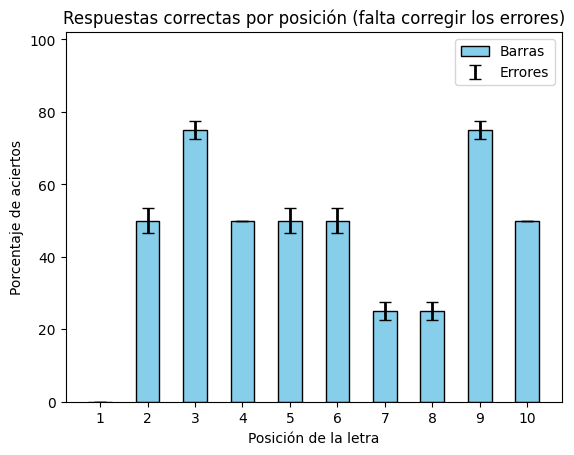

In [27]:
#ploteo
x = np.array(range(1,11)) #ploteo posiciones #plotear el promedio de los porcentajes de cada persona

plt.bar(x, porcentajes_prom, width = 0.5, color='skyblue', edgecolor='black', label='Barras') #gráfico de barras
plt.errorbar(x, porcentajes_prom, yerr=desvest_prom, fmt='none', ecolor='black', elinewidth=2, capsize=4, label='Errores')
plt.legend()
plt.xlabel('Posición de la letra')
plt.ylabel('Porcentaje de aciertos')
plt.ylim(0,102)
plt.xticks(range(1, 11))
plt.title('Respuestas correctas por posición')
plt.show()


correccion de Luz: tenemos que "correr al cero" ("normalizar") las respuestas de cada archivo tomando los tiempos y restandoles la media de cada archivo y dividiensolo por la desviacion estandar.

Despues tenemos que hacer la misma correccion que con los porcentajes de promediar el tiempo de rta por posicion por persona y para el ploteo usar el promedio de esos promedios.

para la cant de archivos uso indice i,
para 30 j,
para 7 k

In [24]:
#(este bloque en realidad no se usa)
#"corro al cero" los tiempos de cada archivo i
tiempos_en0 = []

for i in range(0, cant_archivos):
    nombre_archivo = f'data10_{i}.csv'     #loop que lee cada archivo data_i por vez
    df = pd.read_csv(nombre_archivo)
    tiempo_i = list(df.iloc[:, 5])
    #print(tiempo_i)
    promedio_i = np.mean(tiempo_i)
    desvest_i = np.std(tiempo_i)
    #print(promedio_i)
    for j in range(30):
        tiempos_en0.append((tiempo_i[j]-promedio_i)/desvest_i)

print(tiempos_en0)
print(posicion)
print(len(tiempo),len(tiempos_en0)) #tienen que tener el mismo largo
#en vez de usar el array de tiempo ahotra tenemos ue usar el de t en 0

[2.1293480112048977, 0.5272329549982979, -0.13734594010886406, -0.9047066182013442, 0.43347936921086716, -0.4023309871651779, -0.048923187290816614, -0.9531971702634543, -0.8327222554699499, -0.8924201254108846, 0.3258479700542351, 0.4607692435829601, 1.760394664886758, 0.09306639384700711, 0.7757914377106236, 0.36745578771457194, 0.4420929073202774, 0.23378288819973872, 0.1686065151069562, 0.04941620961746132, 0.43105964013054965, 3.175997882940092, -1.2040445408157, -0.38483252528981465, -0.789632429553545, -0.9857939228930973, -0.9662690137200426, -0.9039121708090285, -1.0187841089172398, -0.9494268806163378, -0.9063559329693122, -0.978591726718, -0.6881149771992718, 0.2831623693975543, -0.7541288224727262, -0.11126537969981175, 1.613734611077726, -0.8874844777656778, 0.28071215208042055, -0.4815432978784916, -1.035129193452141, 1.163359806589708, 0.990909110852152, 0.951233591408169, -0.03097619500331739, 3.233358976359828, -0.4698500609291831, -0.7550163850005803, 0.67184942796568

In [25]:
prom3_1, prom3_2, prom3_3, prom3_4, prom3_5, prom3_6, prom3_7, prom3_8, prom3_9, prom3_10 = [],[],[],[],[],[],[],[],[],[] #promedio de las 3 rtas en cada posicion. prom3_k
dsv3_1, dsv3_2, dsv3_3, dsv3_4, dsv3_5, dsv3_6, dsv3_7, dsv3_8, dsv3_9, dsv3_10 = [],[],[],[],[],[],[],[],[],[] #dsv3_k

for i in range(0, cant_archivos): #leo cada archivo y nombro sus columnas
    nombre_archivo = f'data10_{i}.csv'
    df = pd.read_csv(nombre_archivo)
    posicion_i = list(df.iloc[:, 3])
    respuesta_i = list(df.iloc[:, 4])
    tiempo_i = list(df.iloc[:, 5])

    tiempo_en0_i = [] #normalizo los tiempos
    promedio_i = np.mean(tiempo_i)
    desvest_i = np.std(tiempo_i)
    for j in range(30):
        tiempo_en0_i.append((tiempo_i[j]-promedio_i)/desvest_i) #appendeo de una los 30 tiempos normalizados del archivo i


    for k in range (1, 10+1):
        t3_i_k = [] #lista para+ los 3 tiempos de las rtas por pos. Se vuelve a hacer cada que cambia k (CAMBIA A 2)
        t3_i_k.clear()
        for j in range(30):
            if posicion_i[j] == k:
                if respuesta_i[j] == 1: #cuando responden bien appendeo el tiempo correspondiente a la lista tik
                    t3_i_k.append(tiempo_en0_i[j])
                #else:
                    #print(t3_i_k)

        if len(t3_i_k) == 0:         #ARREGLADO: queda mal cuando no contestaron bien ninguna de las tres, tik queda vacio
            eval(f"prom3_{k}").append(0)
            eval(f"dsv3_{k}").append(0)
        else:
            eval(f"prom3_{k}").append(np.mean(t3_i_k)) #en prom_k guardo el promedio de las 3 rtas por posicion
            eval(f"dsv3_{k}").append(np.std(t3_i_k)/len(t3_i_k)) #guardo el errores de estos promedios

        #print("Datos contienen NaNs:", np.any(np.isnan(prom3_1)))

#print(prom3_1, prom3_2, prom3_3, prom3_4, prom3_5, prom3_6, prom3_7)
#print(dsv3_1, dsv3_2, dsv3_3, dsv3_4, dsv3_5, dsv3_6, dsv3_7, dsv3_8, dsv3_9, dsv3_10)
#hasta aca hice el primedio por persona/archivo del tiempo en cada una delas 10 posiciones.
#queda promediar los tiempos de todos los archivos, por posicion

prom_t_tot = []
err_t_tot = []

for k in range (1, 10+1):
    prom_t_tot.append(np.mean(eval(f"prom3_{k}"))) #hago el promedio de los promedios en cada posicion k
    dsv_array = np.array(eval(f"dsv3_{k}")) #paso a array las dsv
    err_t_tot.append(np.sqrt(sum(dsv_array**2))/cant_archivos) #el error del prom

print(prom_t_tot)
print(err_t_tot)

[0.0, -0.7723244072770626, 1.092563321623268, -0.25053008938856774, 0.4528161580827114, 0.18842181091967608, -0.23492503046459154, 1.0646740056024488, 0.08630085344707822, 0.12072389470708211]
[0.0, 0.0, 0.03895305192560192, 0.11303424787157972, 0.0, 0.0, 0.0, 0.0, 0.20841603387996888, 0.048007894949175726]


si tienes errores diferentes para cada dato, la fórmula para el error del promedio es:la raiz de (la suma de todas las desv est al cuadrado de cada dato), todo dividido n.

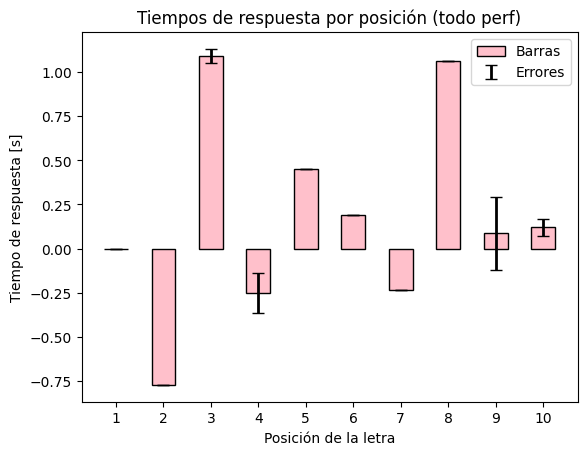

In [28]:
#ploteo
plt.bar(x, prom_t_tot, width = 0.5, color='pink', edgecolor='black', label='Barras') #gráfico derrorbare barras
plt.xlabel('Posición de la letra')
plt.ylabel('Tiempo de respuesta [s]')
plt.errorbar(x, prom_t_tot, yerr=err_t_tot, fmt='none', ecolor='black', elinewidth=2, capsize=4, label='Errores')
plt.legend()
plt.xticks(range(1, 11))
plt.title('Tiempos de respuesta por posición')
plt.show()

#bloques que no se usan

In [ ]:
lista = [2, 2, 3, 5]
rta = []
prom=[]

for i in range(len(lista)):
    if lista[i] == 4:
       rta.append(6)

if len(rta) == 0:
    prom.append(0)
else:
    prom.append(np.mean(rta))

print(rta)
print(prom)


In [ ]:
#errores
Prueba1 = np.array([1,1,1])
Prueba2 = np.array([1,1,0]) #estoy viendo que los promedios por posicion por archivo solo pueden tener desv estandar 0 o 0.15
Prueba3 = np.array([1,0,0])
Prueba4 = np.array([0,0,0])
desvest1 = np.std(Prueba1)/len(Prueba1)
desvest2 = np.std(Prueba2)
desvest3 = np.std(Prueba3)/len(Prueba3)
desvest4 = np.std(Prueba4)/len(Prueba4)
print(desvest1, desvest2, desvest3, desvest4)

In [ ]:
#esto ya no lo usamos
'''
porcentaje = (rtas_corr/(3*cant_archivos))*100 #vector de porcentajes
print(porcentaje) #bue me cagarooon todo ese kilombo para que los porcentajes den igual
'''

In [ ]:
'''
lista1, lista2, lista3, lista4 = [],[],[],[]
for i in range(1, 3):
    for k in range(1, 4+1):
        valor = []
        valor.clear()
        valor.append(k)
        eval(f"lista{k}").append(np.mean(valor))
        print(lista1, lista2, lista3, lista4)
    print(lista1, lista2, lista3, lista4)

lista1.append(8)
print(lista1)
'''

In [ ]:
'''
tiempo_corr = np.array([0.000000]*7) #vector donde sumamos los tiempos de las rtas correctas por posicion

tiempo_pos_1, tiempo_pos_2, tiempo_pos_3, tiempo_pos_4, tiempo_pos_5, tiempo_pos_6, tiempo_pos_7 = [],[],[],[],[],[],[]
for j in range(len(respuesta)):
        if  respuesta[j] == 1:            #miro solo las respuestas correctas
            tiempo_corr[posicion[j]-1] += tiempos_en0[j] #y sumo el tiempo de rta en la posicion correspondiente
print(tiempo_corr)

tiempo_prom = tiempo_corr/rtas_corr #tiempo prom de respuesta por posicion (considerando todos los archivos juntos)
print(tiempo_prom)

for j in range(len(tiempos_en0)): #clasifico los tiempos de rta correctas segun la posicion
             if posicion[j] == 1:
                tiempo_pos_1.append(tiempos_en0[j])
             elif posicion[j] == 2:
                tiempo_pos_2.append(tiempos_en0[j])
             elif posicion[j] == 3:
                tiempo_pos_3.append(tiempos_en0[j])
             elif posicion[j] == 4:
                tiempo_pos_4.append(tiempos_en0[j])
             elif posicion[j] == 5:
                tiempo_pos_5.append(tiempos_en0[j])
             elif posicion[j] == 6:
                tiempo_pos_6.append(tiempos_en0[j])
             elif posicion[j] == 7:
                tiempo_pos_7.append(tiempos_en0[j])
            #if posicion[j] == i+1:
             #   eval(f"tiempo_pos_{i+1}").append(tiempos_en0[j])

tiempo_prom_err=[] #calculo la desviacion en cada posicion
for i in range(len(tiempo_prom)):
  tiempo_prom_err.append(np.std(eval(f"tiempo_pos_{i+1}"))/len(eval(f"tiempo_pos_{i+1}")))
  print(len(eval(f"tiempo_pos_{i+1}")))
print(tiempo_prom_err)
'''